In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install pydicom scikit-image matplotlib numpy opencv-python plotly


Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 31.9 MB/s eta 0:00:00


Loaded volume shape: (508, 512, 512)


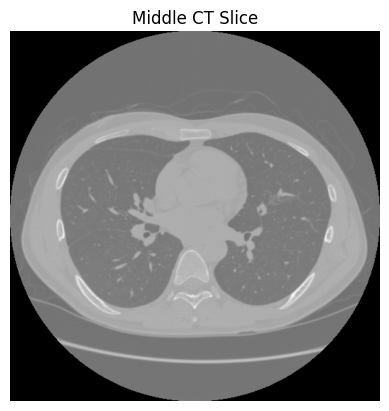

HU range: -3024 to 1694


In [2]:
import os, numpy as np, pydicom, matplotlib.pyplot as plt

dicom_folder = '/content/drive/MyDrive/CT-CASE15'  # update this path if needed

def load_dicom_volume(folder):
    slices = [pydicom.dcmread(os.path.join(folder, f))
              for f in os.listdir(folder) if f.endswith('.dcm')]
    slices.sort(key=lambda x: int(x.InstanceNumber))
    volume = np.stack([s.pixel_array for s in slices])
    return volume, slices

volume, scans = load_dicom_volume(dicom_folder)
print("Loaded volume shape:", volume.shape)

plt.imshow(volume[volume.shape[0]//2], cmap='gray')
plt.title("Middle CT Slice"); plt.axis('off'); plt.show()

def get_pixels_hu(scans):
    image = np.stack([s.pixel_array for s in scans]).astype(np.int16)
    intercept = scans[0].RescaleIntercept
    slope = scans[0].RescaleSlope
    if slope != 1:
        image = slope * image.astype(np.float64)
        image = image.astype(np.int16)
    image += np.int16(intercept)
    return np.array(image, dtype=np.int16)

volume = get_pixels_hu(scans)
print("HU range:", np.min(volume), "to", np.max(volume))


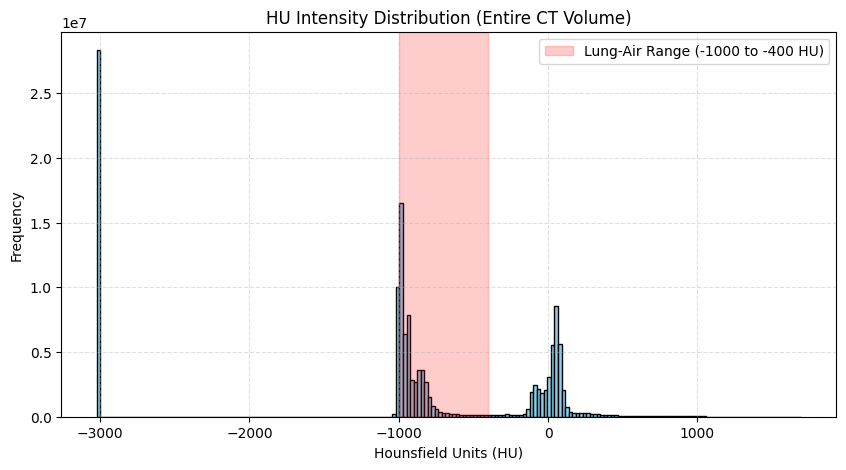

Saved final lung mask: lung_mask_CTCASE15.npy


In [20]:
# Histogram of HU values for the entire CT volume
flattened = volume.flatten()

plt.figure(figsize=(10,5))
plt.hist(flattened, bins=200, color='skyblue', edgecolor='k')
plt.title("HU Intensity Distribution (Entire CT Volume)")
plt.xlabel("Hounsfield Units (HU)")
plt.ylabel("Frequency")

# Highlight
plt.axvspan(-1000, -400, color='red', alpha=0.2, label='Lung-Air Range (-1000 to -400 HU)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

np.save('/content/HU_intensity.npy', flattened)
print("Saved final lung mask: lung_mask_CTCASE15.npy")


In [19]:
import cv2
from skimage import measure, morphology
from skimage.segmentation import clear_border
from scipy import ndimage

def lung_segmentation_threshold(slice_img):

    mask = np.logical_and(slice_img > -1000, slice_img < -400).astype(np.uint8)


    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((7,7), np.uint8))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((7,7), np.uint8))


    labels = measure.label(mask)
    props = measure.regionprops(labels)
    good_labels = [p.label for p in props if p.area > 1000]
    mask = np.isin(labels, good_labels)


    mask = morphology.binary_dilation(mask, np.ones((8,8)))
    return mask.astype(np.uint8)


lung_mask_slices = np.stack([lung_segmentation_threshold(s) for s in volume])


lung_mask_slices = clear_border(lung_mask_slices)
lung_mask_slices = ndimage.binary_opening(lung_mask_slices, structure=np.ones((3,3,3)))
lung_mask_slices = lung_mask_slices.astype(np.uint8)


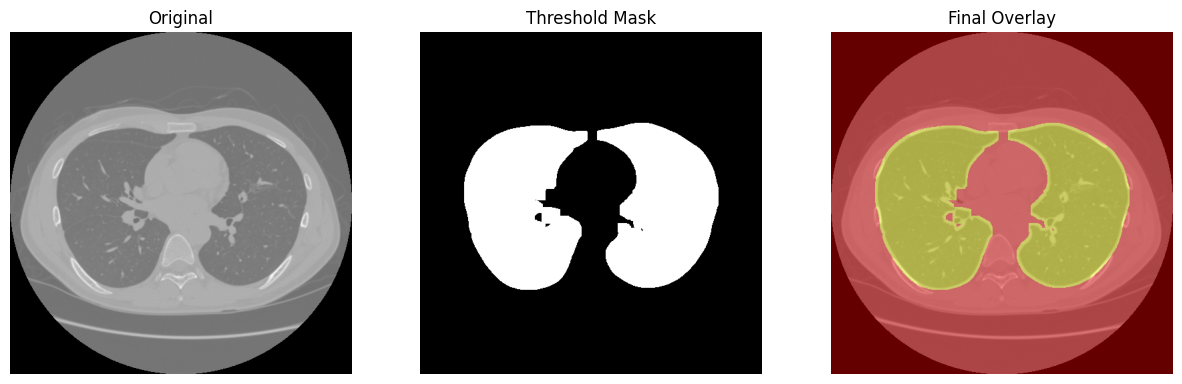

In [21]:
idx = volume.shape[0] // 2
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(volume[idx], cmap='gray'); plt.title('Original'); plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(lung_mask_slices[idx], cmap='gray'); plt.title('Threshold Mask'); plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(volume[idx], cmap='gray')
plt.imshow(lung_mask_slices[idx], alpha=0.4, cmap='autumn')
plt.title('Final Overlay'); plt.axis('off')

plt.show()

np.save('/content/lung_mask_CTCASE15.png', lung_mask_slices)



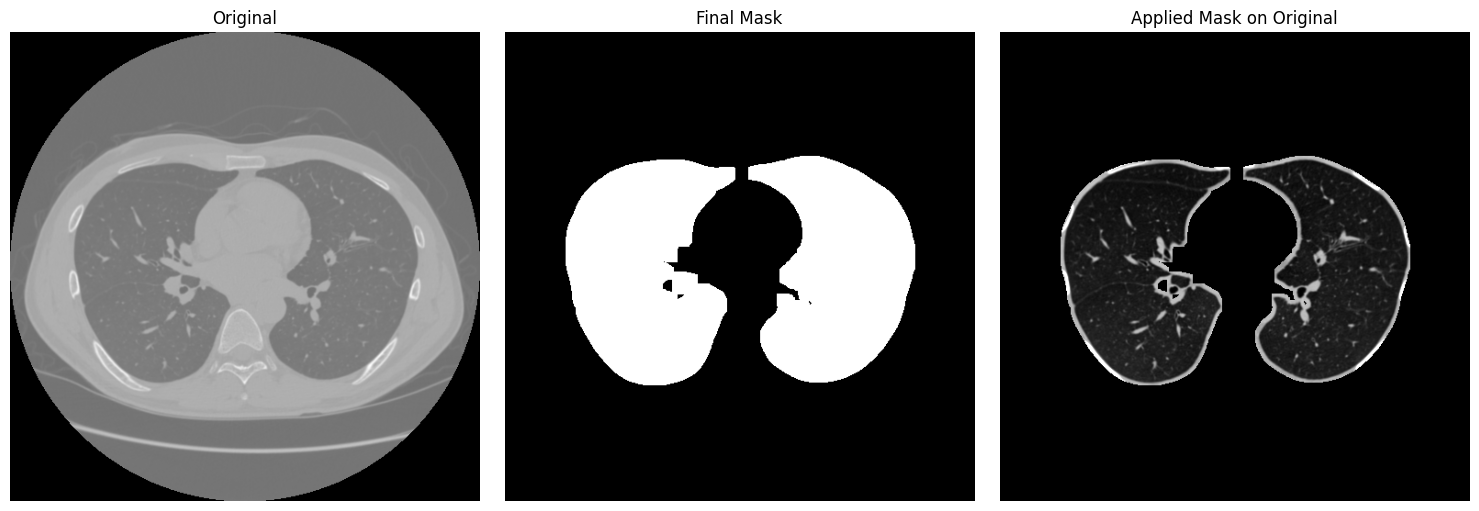

Saved visualization image
Saved final lung mask: lung_mask_CTCASE15.npy


<Figure size 640x480 with 0 Axes>

In [22]:
idx = volume.shape[0] // 2
slice_original = np.clip(volume[idx], -1000, 400)
slice_original = (slice_original - np.min(slice_original)) / (np.max(slice_original) - np.min(slice_original))

masked_slice = slice_original * lung_mask_slices[idx]

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(volume[idx], cmap='gray'); plt.title('Original'); plt.axis('off')


plt.subplot(1,3,2)
plt.imshow(lung_mask_slices[idx], cmap='gray')
plt.title('Final Mask'); plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(masked_slice, cmap='gray')
plt.title('Applied Mask on Original'); plt.axis('off')

plt.tight_layout()
plt.show()

plt.savefig('/content/lung_mask_visualization_CTCASE15.png', dpi=300, bbox_inches='tight')
print("Saved visualization image")


np.save('/content/final_lung_mask_CTCASE15.npy', lung_mask_slices)
print("Saved final lung mask: lung_mask_CTCASE15.npy")


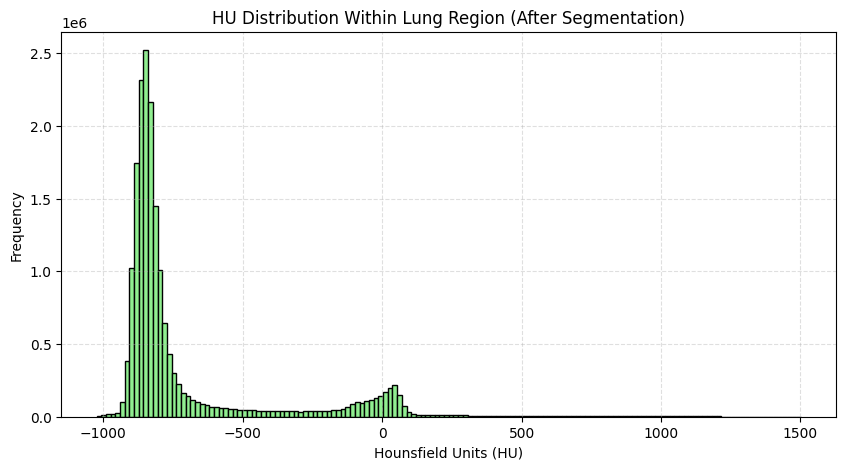

In [23]:
# Extract only voxels inside the segmented lungs
lung_voxels = volume[lung_mask_slices > 0]

plt.figure(figsize=(10,5))
plt.hist(lung_voxels, bins=150, color='lightgreen', edgecolor='k')
plt.title("HU Distribution Within Lung Region (After Segmentation)")
plt.xlabel("Hounsfield Units (HU)")
plt.ylabel("Frequency")
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()


In [24]:
from skimage.segmentation import flood
from scipy import ndimage
import numpy as np
import matplotlib.pyplot as plt


In [25]:
#pick a seed slice near top of scan
z_seed = volume.shape[0] // 6
slice_img = volume[z_seed]

#find darkest pixel near image center
crop = slice_img[180:330, 180:330]
seed_rel = np.unravel_index(np.argmin(crop), crop.shape)
seed_point = (seed_rel[0] + 180, seed_rel[1] + 180, z_seed)
print("Seed point (y, x, z):", seed_point)

# 3D Region Growing (airway intensity ≈ –800 → –600 HU)
airway_mask = flood(volume, seed_point, tolerance=200)

#Restrict to inside lungs
airway_mask = np.logical_and(airway_mask, lung_mask_slices)

#Morphological cleanup
airway_mask = ndimage.binary_opening(airway_mask, structure=np.ones((3,3,3)))
airway_mask = ndimage.binary_closing(airway_mask, structure=np.ones((3,3,3)))
airway_mask = airway_mask.astype(np.uint8)


Seed point (y, x, z): (np.int64(253), np.int64(246), 84)


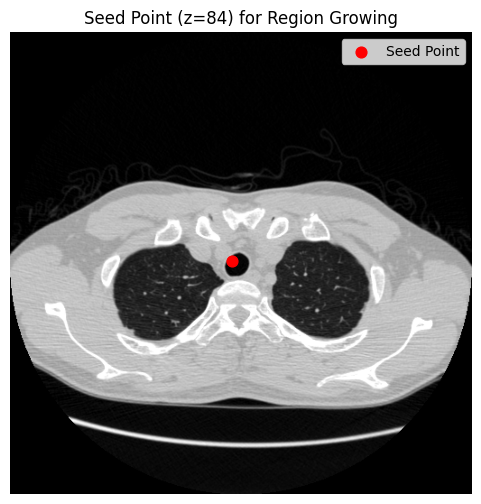

In [10]:

plt.figure(figsize=(6,6))
plt.imshow(slice_img, cmap='gray', vmin=-1000, vmax=400)
plt.scatter(seed_point[1], seed_point[0], color='red', s=60, label='Seed Point')
plt.title(f"Seed Point (z={z_seed}) for Region Growing")
plt.legend()
plt.axis('off')
plt.show()


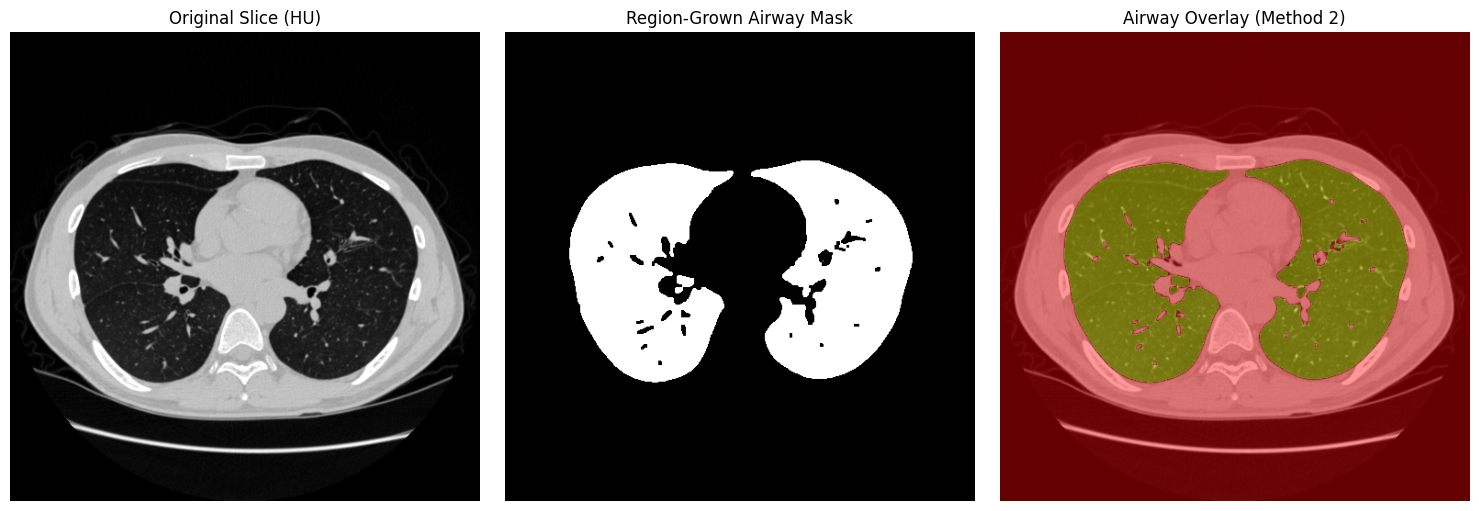

In [26]:
mid = volume.shape[0] // 2
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(volume[mid], cmap='gray', vmin=-1000, vmax=400)
plt.title('Original Slice (HU)'); plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(airway_mask[mid], cmap='gray')
plt.title('Region-Grown Airway Mask'); plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(volume[mid], cmap='gray', vmin=-1000, vmax=400)
plt.imshow(airway_mask[mid], alpha=0.4, cmap='autumn')
plt.title('Airway Overlay (Method 2)'); plt.axis('off')

plt.tight_layout()
plt.show()


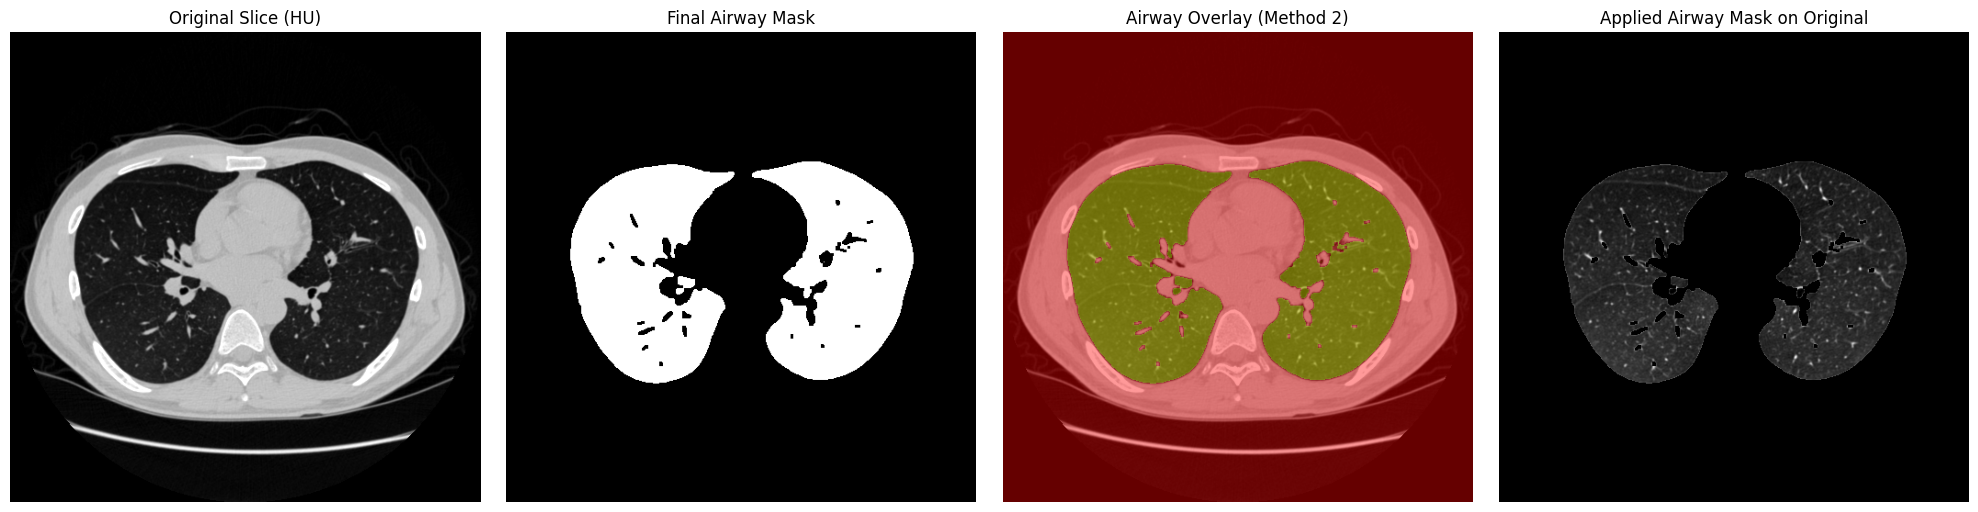

In [27]:
idx = volume.shape[0] // 2
slice_original = np.clip(volume[idx], -1000, 400)
slice_original = (slice_original - np.min(slice_original)) / (np.max(slice_original) - np.min(slice_original))

masked_airway = slice_original * airway_mask[idx]

plt.figure(figsize=(20,5))

plt.subplot(1,4,1)
plt.imshow(volume[mid], cmap='gray', vmin=-1000, vmax=400)
plt.title('Original Slice (HU)'); plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(airway_mask[idx], cmap='gray')
plt.title('Final Airway Mask'); plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(volume[mid], cmap='gray', vmin=-1000, vmax=400)
plt.imshow(airway_mask[mid], alpha=0.4, cmap='autumn')
plt.title('Airway Overlay (Method 2)'); plt.axis('off')

plt.subplot(1,4,4)
plt.imshow(masked_airway, cmap='gray')
plt.title('Applied Airway Mask on Original'); plt.axis('off')

plt.tight_layout()
plt.show()


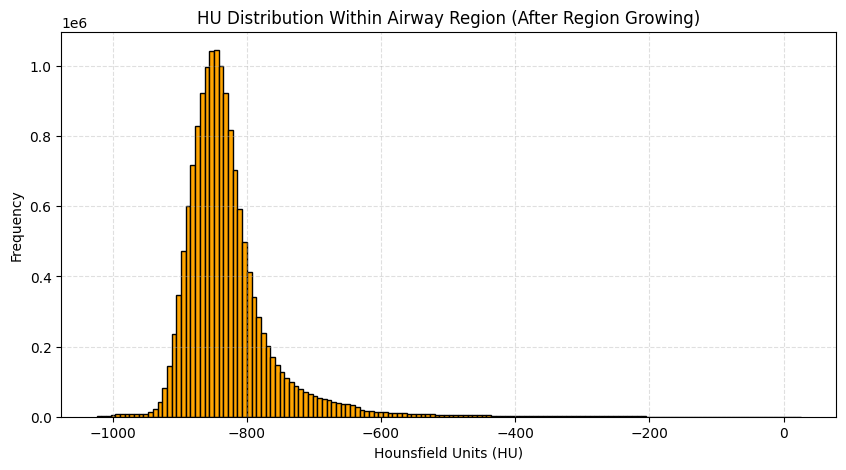

In [28]:
# Extract HU values only from the airway region
airway_voxels = volume[airway_mask > 0]

plt.figure(figsize=(10,5))
plt.hist(airway_voxels, bins=150, color='orange', edgecolor='k')
plt.title("HU Distribution Within Airway Region (After Region Growing)")
plt.xlabel("Hounsfield Units (HU)")
plt.ylabel("Frequency")
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()


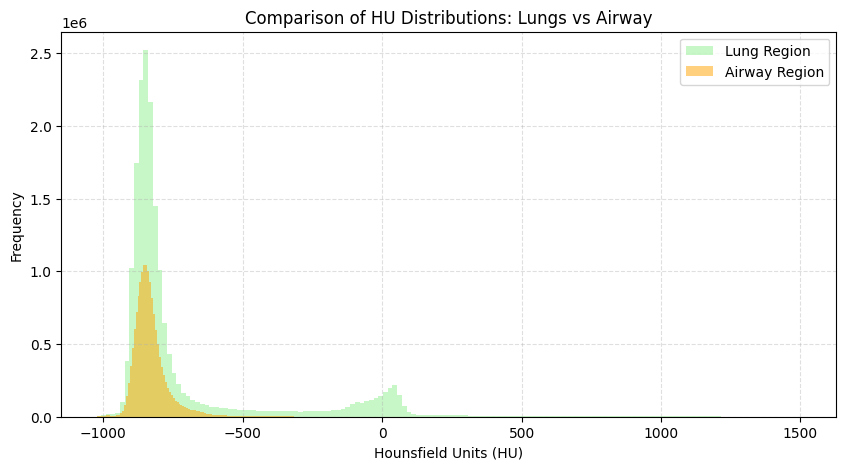

In [29]:
plt.figure(figsize=(10,5))
plt.hist(lung_voxels, bins=150, color='lightgreen', alpha=0.5, label='Lung Region')
plt.hist(airway_voxels, bins=150, color='orange', alpha=0.5, label='Airway Region')
plt.title("Comparison of HU Distributions: Lungs vs Airway")
plt.xlabel("Hounsfield Units (HU)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()
